In [1]:
import utils
import methods
from utils import DataGenerator, Reservoir

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import scipy.io as sio
from scipy.signal import welch
from scipy.stats import ks_2samp

# Data Analysis

In the following we aim to analyze the datasets considered in our implementation of a Reservoir Computer for time series forcasting. 

In general a time series represents a record of observations of dynamical system at specific time intervals. Time series prediction involeved predicting the next state of the system given the current state, and it is very challenging in the case of chaotic dynamical systems as they are characterized by orbital instability, meaning predictions are only feasible in a relatively short time.

Recurrent Neural Networks (RNN) serve are the mainstream architecture for analysing sequential data. This is due to the architecture having recurrent connections, which serve as a notion of memory, allowing them to embed temporal information.

We implement three training approachs: 
+ Bayesian Inference over the regression parameter: via MCMC and stochastic Variatonal Inference (VI),
+ Quantile Regression (QR),
with the goal of obtaining along-side the prediction its uncertainty.

To evaluate the performance of these approaches in multi-step forecasting of chaotic time-series we use a chatic benchmark and two experimental datasets containing rs-fMRI brain signal from the same subject.



## Real dataset

We load the real fMRI time series and compare basic statistics, power spectra and autocorrelations with the synthetic Mackey–Glass series.

In [2]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [3]:
real_data = torch.from_numpy(mat_file['tseries']).float().T
real_np = real_data.cpu().numpy()
real_np.shape

(1200, 119)

### Understand `real_data`

We standardize the real dataset to a `(time, regions)` NumPy array, verify shapes, missing values, and basic statistics. This prepares the data for progressive analyses (heatmaps, PSD, correlations).

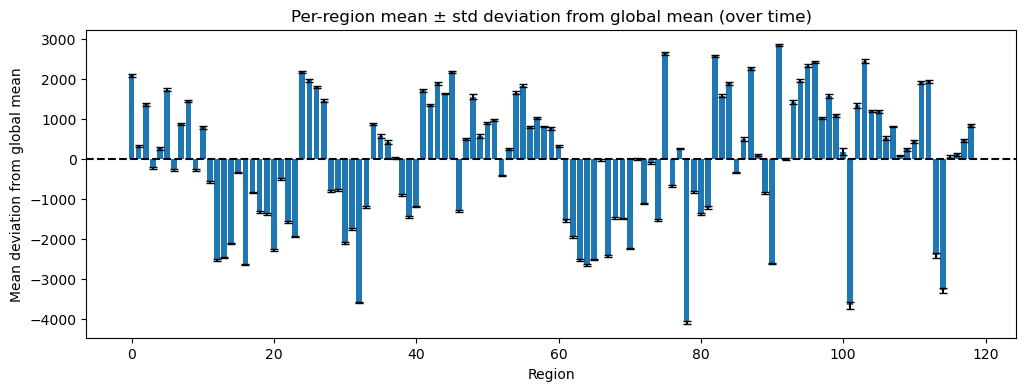

In [4]:
# compute deviations from the global mean time-series
global_mean = real_np.mean(axis=1)                # shape: (time,)
dev = real_np - global_mean[:, None]              # shape: (time, regions)

region_dev_mean = dev.mean(axis=0)
region_dev_std  = dev.std(axis=0)

plt.figure(figsize=(12,4))
plt.bar(np.arange(len(region_dev_mean)), region_dev_mean, yerr=region_dev_std, capsize=3)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Region')
plt.ylabel('Mean deviation from global mean')
plt.title('Per-region mean ± std deviation from global mean (over time)')
plt.show()

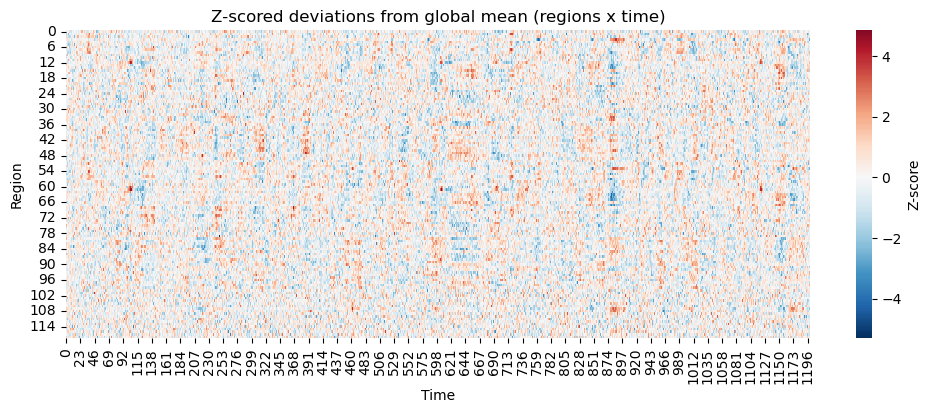

In [5]:
# Heatmap of z-scored deviations (time x regions)
dev_z = (dev - dev.mean(axis=0)) / (dev.std(axis=0) + 1e-8)
plt.figure(figsize=(12,4))
sns.heatmap(dev_z.T, cmap='RdBu_r', center=0, cbar_kws={'label':'Z-score'})
plt.title('Z-scored deviations from global mean (regions x time)')
plt.xlabel('Time')
plt.ylabel('Region')
plt.show()

In [6]:
real_data_z = (real_np - real_np.mean(axis=0)) / (real_np.std(axis=0)  + 1e-8)

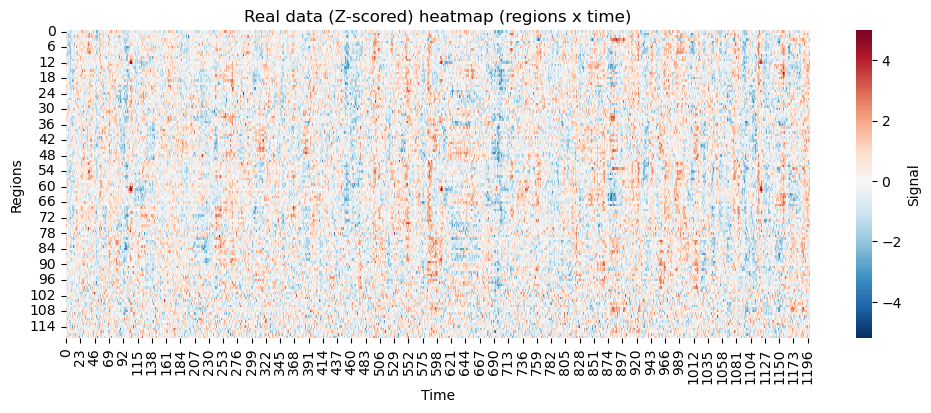

In [7]:
# Heatmap of real data (time x regions)
plt.figure(figsize=(12,4))
sns.heatmap(real_data_z.T, cmap='RdBu_r', center=0, cbar_kws={'label':'Signal'})
plt.title('Real data (Z-scored) heatmap (regions x time)')
plt.xlabel('Time')
plt.ylabel('Regions')
plt.show()

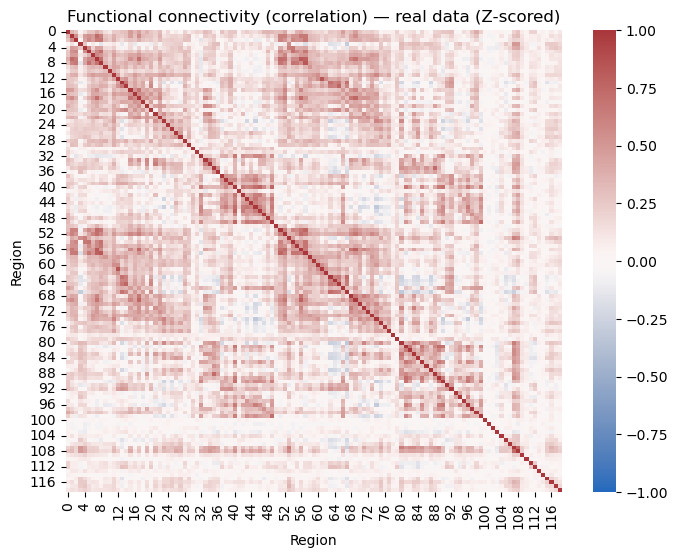

In [8]:
# Functional connectivity (correlation) across regions — use the full available time window
corr = np.corrcoef(real_data_z.T)  # regions x regions
plt.figure(figsize=(8,6))
sns.heatmap(corr, vmin=-1, vmax=1, cmap='vlag')  #, cbar_kws={'label':'Pearson r'})
plt.title('Functional connectivity (correlation) — real data (Z-scored)')
plt.xlabel('Region')
plt.ylabel('Region')
plt.show()

## Synthetic Dataset

### Mackey–Glass Equation

The Mackey–Glass delay differential equation (continuous form):

$$
\frac{dx(t)}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

We use a discrete Euler approximation in the generator implemented in this notebook:

$$
x_{t+\Delta t} = x_t + \Delta t \left( \beta \frac{x_{t-\tau}}{1 + x_{t-\tau}^n} - \gamma x_t \right)
$$

Where: $\tau$ is the delay, $n$ the nonlinearity exponent, $\beta$ and $\gamma$ are parameters controlling feedback and decay, and $\Delta t$ is the integration step.

In [14]:
Time_steps = real_data.shape[0]
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

synth_data, _ = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()

synth_np = np.asarray(synth_data).squeeze()

print('synthetic data shape:', np.asarray(synth_data).shape)
print('synth (1D) length:', len(synth_np))

1700 (13702,) 0.0
synthetic data shape: (12000, 1)
synth (1D) length: 12000


# Comparison

In [10]:
# Global summaries
real_n_time, real_n_regions = real_np.shape
synth_n_time = len(synth_np)
real_n_nans = int(np.isnan(real_np).sum())
synth_n_nans = int(np.isnan(synth_np).sum())

global_rows = [
    {
        'dataset': 'real (global)',
        'n_timepoints': real_n_time,
        'n_regions': real_n_regions,
        'min': float(np.nanmin(real_np)),
        'max': float(np.nanmax(real_np)),
        'mean': float(np.nanmean(real_np)),
        'std': float(np.nanstd(real_np)),
        'n_nans': real_n_nans
    },
    {
        'dataset': 'synthetic',
        'n_timepoints': synth_n_time,
        'n_regions': pd.NA,
        'min': float(np.nanmin(synth_np)),
        'max': float(np.nanmax(synth_np)),
        'mean': float(np.nanmean(synth_np)),
        'std': float(np.nanstd(synth_np)),
        'n_nans': synth_n_nans
    }
]

df_global = pd.DataFrame(global_rows).set_index('dataset')
display(df_global.style.format({
    'min': '{:.4f}', 'max': '{:.4f}', 'mean': '{:.4f}', 'std': '{:.4f}',
    'n_timepoints': '{:.0f}', 'n_nans': '{:.0f}'
}))

,n_timepoints,n_regions,min,max,mean,std,n_nans
dataset,,,,,,,
real (global),1200,119,6342.3433,13489.3506,10541.8740,1606.5990,0
synthetic,12000,,0.0000,0.0000,0.0000,0.0000,0


In [11]:
region_idx = np.random.choice(np.arange(real_data.shape[1]))
real_region_z = real_data_z[:, region_idx]

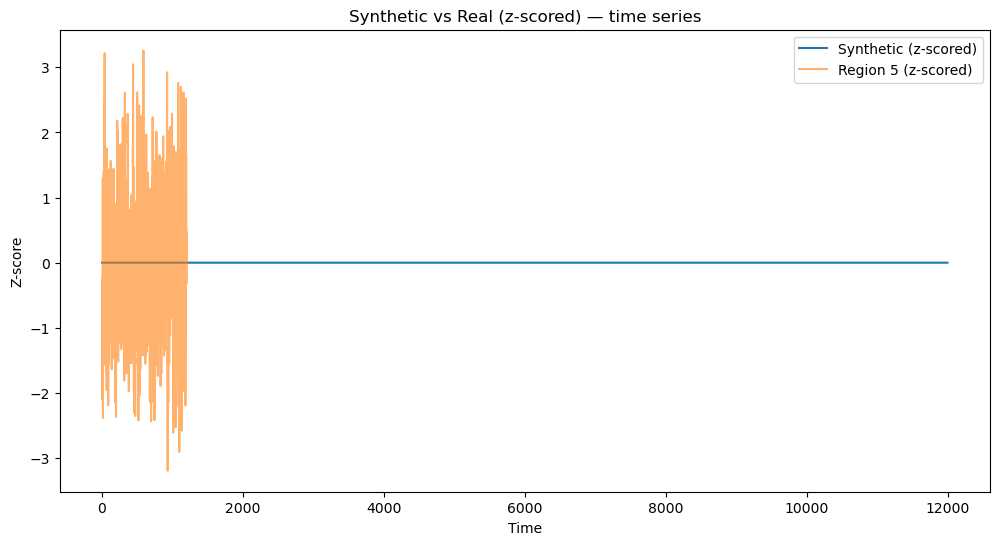

In [12]:
# Visualize stacked plots

plt.figure(figsize=(12,6))
plt.plot(synth_data, label='Synthetic (z-scored)')
plt.plot(real_region_z, alpha=0.6, label=f'Region {region_idx} (z-scored)')
plt.legend()
plt.title('Synthetic vs Real (z-scored) — time series')
plt.xlabel('Time')
plt.ylabel('Z-score')
plt.show()

/Users/Filippo/miniconda3/envs/probabilistic_RC/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 1, using nperseg = 1
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


ValueError: x and y must have same first dimension, but have shapes (1,) and (12000, 1)

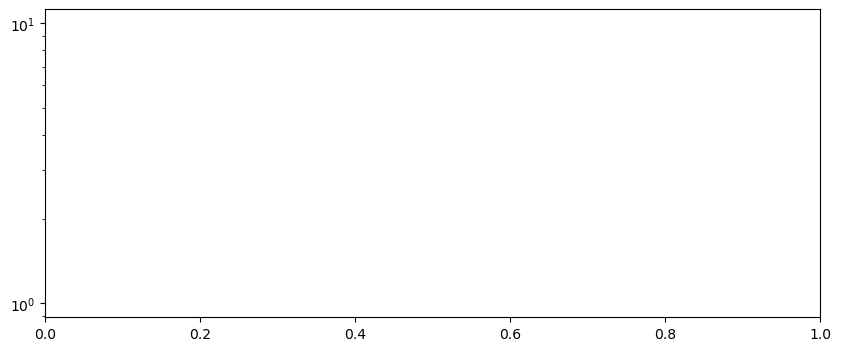

In [13]:
# Power Spectral Density (PSD) comparison (Welch) for the selected region
fs = 1.0  # sample frequency (arbitrary units)

f_s, P_s = welch(synth_data, fs=fs, nperseg=min(256, len(synth_data)))
f_r, P_r = welch(real_region_z, fs=fs, nperseg=min(256, len(real_region_z)))

plt.figure(figsize=(10,4))
plt.semilogy(f_s, P_s, label='Synthetic PSD')
plt.semilogy(f_r, P_r, label=f'Real region {region_idx} PSD')
plt.xlabel('Frequency (arbitrary units)')
plt.ylabel('PSD')
plt.legend()
plt.title('Welch PSD: Synthetic vs Real (selected region)')
plt.show()

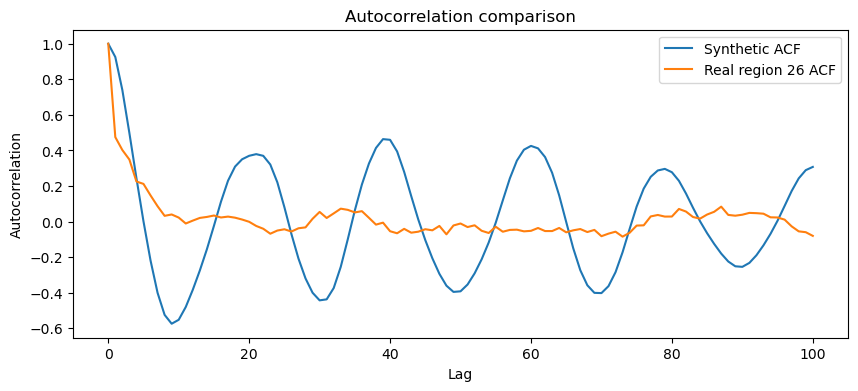

In [ ]:
# Autocorrelation function
def autocorr(x, nlags=100):
    x = x - np.mean(x)
    corr = np.correlate(x, x, mode='full')
    mid = len(corr) // 2
    ac = corr[mid:mid+nlags+1] / corr[mid]
    return ac

nlags = 100
ac_s = autocorr(synth_data_z, nlags)
ac_r = autocorr(real_region_z, nlags)

plt.figure(figsize=(10,4))
plt.plot(ac_s, label='Synthetic ACF')
plt.plot(ac_r, label=f'Real region {region_idx} ACF')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.legend()
plt.title('Autocorrelation comparison')
plt.show()